# Interpretación del modelo Seleccionado

### By:
Karen Ninco

### Date:
2026-08-26

# Requerimiento
Analizar las características del modelo obtenido, con el fin de tener un listado de pruebas y experimentos que se van a realizar en la siguiente iteración. Crear un nuevo branch de git (Usar [Gitflow](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/)).

> Tomar como ejemplo los pasos de: <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/>

En este proceso se incluye :

- Interpretar el modelo seleccionado
- Identificar los atributos más importantes
- Realizar el análisis de Learning curve
- obtener las gráficas de escalabilidad con tiempo de entrenamiento y score
- ¿Cuáles son las consecuencias de las malas predicciones?
- ¿Qué tipo de errores comete el modelo?
- ¿A qué se deben los errores?
    - outliers?
    - Clase desbalanceada?
    - ¿Errores en el ingreso de datos?
    - Encoders?
    - etc

> Puede utilizar las librerías o herramientas que considere para resolver la tarea


# Entregables
Notebook con los pasos descritos anteriormente y el modelo entrenado en formato  `.joblib`

Se debe realizar un Pull request para ingresar el notebook a la rama`main` para esto debe tener mínimo 1 revisiones de otras personas del Curso y que pase los check del CI/CD.


### Description:

Se interpreta el modelo Random Forest seleccionado en la Actividad 6 (Selección del mejor modelo, [06.ModelSelection-kgnl-20260825.ipynb](../5-models/06.ModelSelection-kgnl-20260825.ipynb)), reutilizando el mismo pipeline de preprocesamiento, las mismas `selected_features` y el mismo split train/test (`random_state=42`). Se analiza la importancia de las variables (Feature Importance MDI y Permutation Importance), la Learning Curve y la escalabilidad del modelo final, y se realiza un análisis de los casos mal clasificados sobre el conjunto de prueba.

## 📚 Import  libraries

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import load
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import ShuffleSplit, learning_curve, train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

print("Pandas version: ", pd.__version__)

Pandas version:  3.0.5


## 💾 Load model

In [23]:
MODEL_DIR = Path.cwd().resolve().parents[1] / "models"
corazon_model = load(MODEL_DIR / "corazon_classification-model-v1.joblib")
corazon_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['age','sex','chest_pain',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('boolean', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rema

### Verificación del preprocessor reutilizado

Se confirma que el `preprocessor` cargado dentro del modelo guardado usa exactamente la misma configuración de la Actividad 6: `OneHotEncoder(handle_unknown="ignore")` para las variables categóricas nominales y `OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)` para `slope`.

In [24]:
onehot_encoder = (
    corazon_model["preprocessor"].named_transformers_["categoric"].named_steps["onehot"]
)
ordinal_encoder = (
    corazon_model["preprocessor"]
    .named_transformers_["categoric ordinales"]
    .named_steps["onehot"]
)

assert isinstance(onehot_encoder, OneHotEncoder)
assert isinstance(ordinal_encoder, OrdinalEncoder)
print("OneHotEncoder handle_unknown:", onehot_encoder.handle_unknown)
print(
    "OrdinalEncoder handle_unknown:",
    ordinal_encoder.handle_unknown,
    "| unknown_value:",
    ordinal_encoder.unknown_value,
)

OneHotEncoder handle_unknown: ignore
OrdinalEncoder handle_unknown: use_encoded_value | unknown_value: -1


## 🔁 Reconstruir el dataset y el split de train / test (Actividad 6)

Se reproducen exactamente los mismos pasos de la Actividad 6 (Selección del mejor modelo, [06.ModelSelection-kgnl-20260825.ipynb](../5-models/06.ModelSelection-kgnl-20260825.ipynb)): mismas `selected_features`, misma limpieza (filas sin `disease`, duplicados) y mismo `train_test_split` con `random_state=42`, para poder evaluar el modelo cargado sobre el mismo conjunto de prueba (95 filas) con el que fue seleccionado.

In [25]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
corazon_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/corazon_clean.parquet", engine="pyarrow"
)

In [26]:
selected_features = [
    "age",
    "sex",
    "chest_pain",
    "chol",
    "rest_ecg",
    "max_hr",
    "exang",
    "old_peak",
    "slope",
    "ca",
    "thal",
    "disease",
]
corazon_features = corazon_df[selected_features]
corazon_features = corazon_features.dropna(subset=["disease"])
corazon_features.loc[:, "disease"] = corazon_features["disease"].astype(int)
corazon_features = corazon_features.drop_duplicates()
corazon_features.info()

<class 'pandas.DataFrame'>
Index: 473 entries, 0 to 1496
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         456 non-null    float64 
 1   sex         424 non-null    category
 2   chest_pain  402 non-null    category
 3   chol        401 non-null    float64 
 4   rest_ecg    357 non-null    category
 5   max_hr      383 non-null    Int16   
 6   exang       402 non-null    boolean 
 7   old_peak    403 non-null    float64 
 8   slope       403 non-null    category
 9   ca          426 non-null    Int8    
 10  thal        441 non-null    category
 11  disease     473 non-null    boolean 
dtypes: Int16(1), Int8(1), boolean(2), category(5), float64(3)
memory usage: 21.6 KB


In [27]:
X_features = corazon_features.drop("disease", axis="columns")
Y_target = corazon_features["disease"]

# 80% train, 20% test
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target, random_state=42
)
x_train.shape, x_test.shape

((378, 11), (95, 11))

## 🌲 Feature Importance (MDI)

Se calcula la importancia de las variables a partir de la disminución media de impureza (Mean Decrease in Impurity, MDI) del Random Forest cargado: `corazon_model["model"].feature_importances_`, con los nombres de las variables transformadas obtenidos de `corazon_model["preprocessor"].get_feature_names_out()`. La desviación estándar se calcula entre los árboles individuales del bosque (`corazon_model["model"].estimators_`).

In [28]:
feature_names = corazon_model["preprocessor"].get_feature_names_out()
importances = corazon_model["model"].feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in corazon_model["model"].estimators_], axis=0
)

mdi_importances = (
    pd.DataFrame({"feature": feature_names, "importance": importances, "std": std})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
mdi_importances

,feature,importance,std
0,numeric__ca,0.129687,0.053974
1,numeric__old_peak,0.111924,0.048110
2,numeric__age,0.110260,0.043112
3,numeric__max_hr,0.107415,0.053242
4,numeric__chol,0.097622,0.038527
5,categoric__thal_normal,0.084056,0.084581
6,categoric__chest_pain_asymptomatic,0.081602,0.059887
7,categoric__thal_reversable,0.067729,0.073137
8,categoric ordinales__slope,0.059380,0.040011
9,boolean__exang,0.035387,0.033625


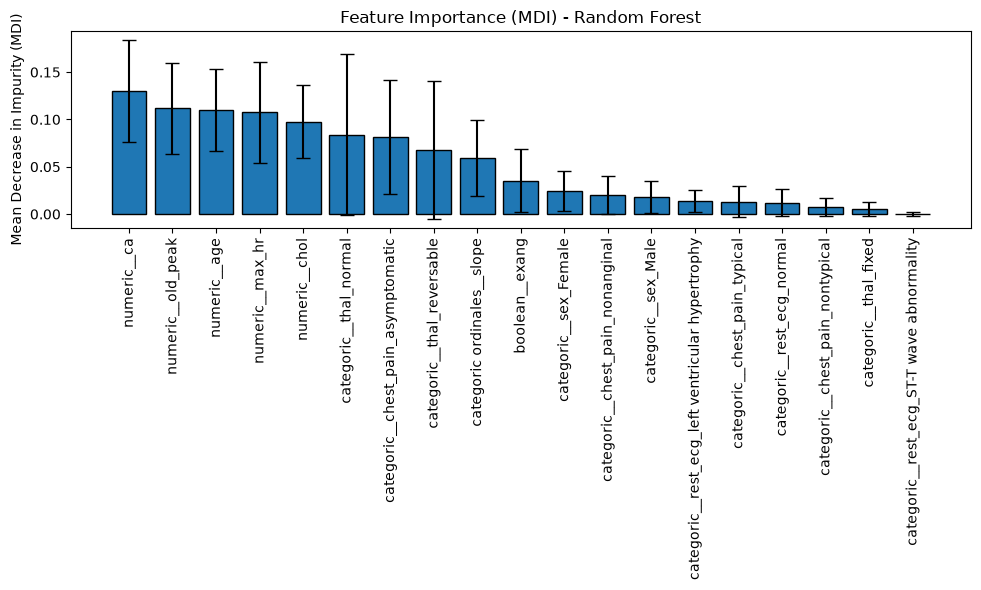

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    mdi_importances["feature"],
    mdi_importances["importance"],
    yerr=mdi_importances["std"],
    capsize=5,
    edgecolor="black",
)
ax.set_ylabel("Mean Decrease in Impurity (MDI)")
ax.set_title("Feature Importance (MDI) - Random Forest")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 🔀 Permutation Importance

Se calcula la Permutation Importance sobre el conjunto de prueba (`x_test`, `y_test`), usando `scoring="recall"` (la métrica priorizada en este proyecto por su relevancia clínica, ver Actividad 6), con `n_repeats=10` y `random_state=42`.

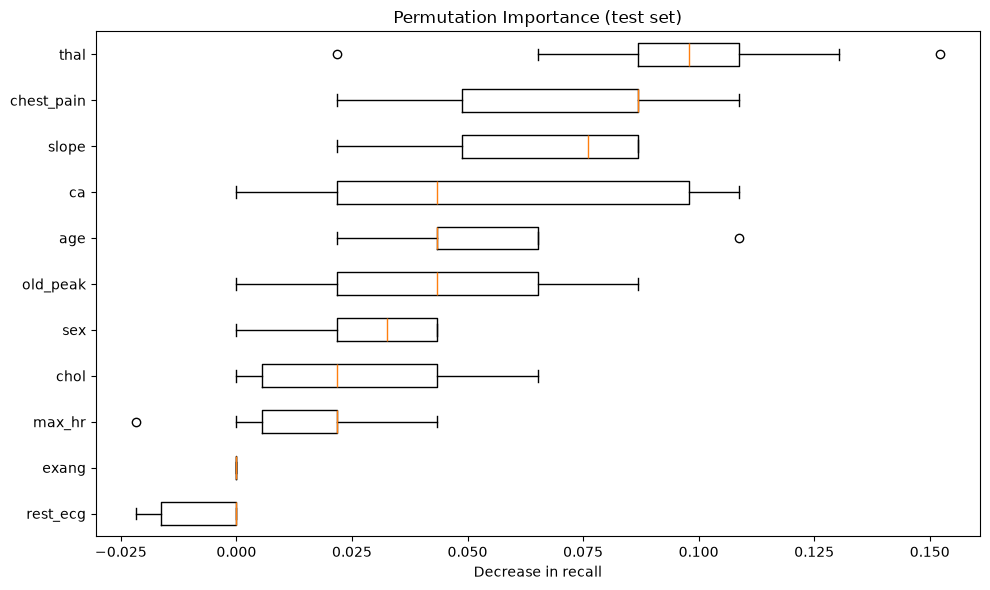

In [30]:
perm_importance = permutation_importance(
    corazon_model,
    x_test,
    y_test,
    scoring="recall",
    n_repeats=10,
    random_state=42,
)

perm_sorted_idx = perm_importance.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    perm_importance.importances[perm_sorted_idx].T,
    orientation="horizontal",
    tick_labels=x_test.columns[perm_sorted_idx],
)
ax.set_xlabel("Decrease in recall")
ax.set_title("Permutation Importance (test set)")
plt.tight_layout()
plt.show()

## 📈 Learning Curve

Se recalcula la Learning Curve sobre el modelo final cargado (`corazon_model`), con el mismo código y los mismos parámetros que en la Actividad 6: `ShuffleSplit(n_splits=50, test_size=0.2, random_state=123)`, `train_sizes=np.linspace(0.1, 1.0, 5)` y `scoring="recall"`.

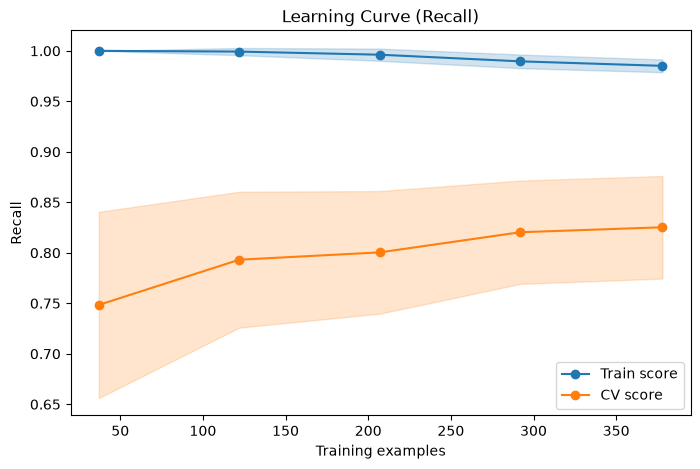

In [31]:
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    corazon_model,
    X_features,
    Y_target,
    cv=ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="recall",
    return_times=True,
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
test_scores_mean = test_scores.mean(axis=1)
test_scores_std = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores_mean, "o-", color="tab:blue", label="Train score")
ax.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2,
    color="tab:blue",
)
ax.plot(train_sizes, test_scores_mean, "o-", color="tab:orange", label="CV score")
ax.fill_between(
    train_sizes,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2,
    color="tab:orange",
)
ax.set_xlabel("Training examples")
ax.set_ylabel("Recall")
ax.set_title("Learning Curve (Recall)")
ax.legend(loc="best")
plt.show()

In [32]:
print("Training Sizes:", train_sizes)
print("Train Scores Mean:", train_scores_mean)
print("Train Scores Std:", train_scores_std)
print("CV Scores Mean:", test_scores_mean)
print("CV Scores Std:", test_scores_std)

Training Sizes: [ 37 122 207 292 378]
Train Scores Mean: [1.         0.9992764  0.99618591 0.9896079  0.98515209]
Train Scores Std: [0.         0.00355223 0.00602965 0.00673719 0.00629667]
CV Scores Mean: [0.74839137 0.79317168 0.80042023 0.82037198 0.82528502]
CV Scores Std: [0.09218034 0.0672669  0.06070701 0.05117794 0.05078009]


## ⏱️ Escalabilidad del modelo

Se grafican los tiempos de ajuste (`fit_times`) y predicción (`score_times`) obtenidos en la Learning Curve, en función del tamaño del conjunto de entrenamiento.

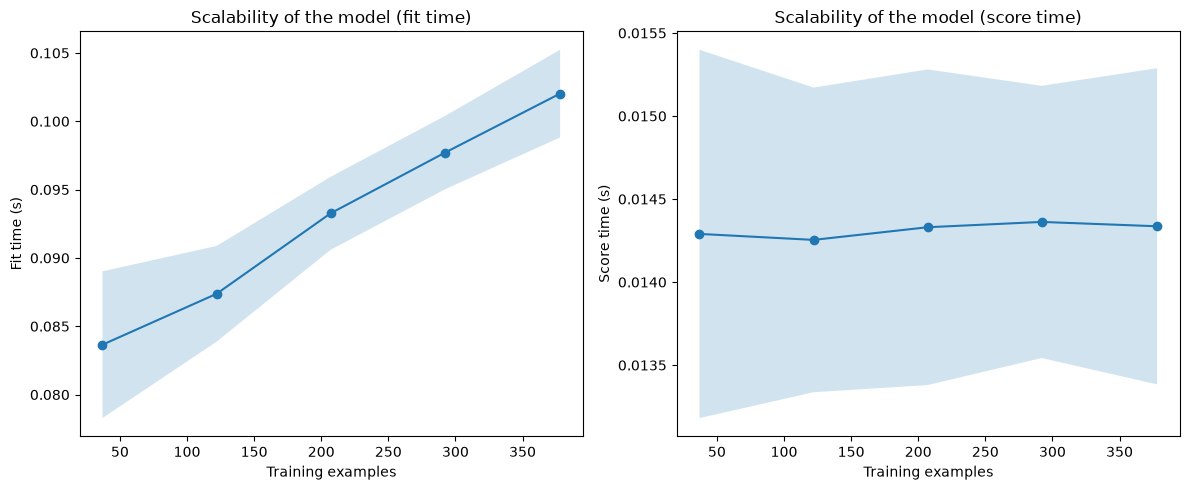

In [33]:
fit_times_mean = fit_times.mean(axis=1)
fit_times_std = fit_times.std(axis=1)
score_times_mean = score_times.mean(axis=1)
score_times_std = score_times.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_sizes, fit_times_mean, "o-")
axes[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.2,
)
axes[0].set_xlabel("Training examples")
axes[0].set_ylabel("Fit time (s)")
axes[0].set_title("Scalability of the model (fit time)")

axes[1].plot(train_sizes, score_times_mean, "o-")
axes[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.2,
)
axes[1].set_xlabel("Training examples")
axes[1].set_ylabel("Score time (s)")
axes[1].set_title("Scalability of the model (score time)")

plt.tight_layout()
plt.show()

In [34]:
print("Fit Times Mean:", fit_times_mean)
print("Fit Times Std:", fit_times_std)
print("Score Times Mean:", score_times_mean)
print("Score Times Std:", score_times_std)

Fit Times Mean: [0.08365366 0.08737621 0.09326862 0.09769638 0.10202915]
Fit Times Std: [0.00537027 0.00350275 0.00267107 0.00268457 0.00320684]
Score Times Mean: [0.01429017 0.01425424 0.01433039 0.01436238 0.01433621]
Score Times Std: [0.00110896 0.00091735 0.00095029 0.00081969 0.00095194]


## 🔍 Análisis de errores

Se generan las predicciones del modelo sobre `x_test` y se identifican los casos mal clasificados (`y_pred != y_test`), para revisar la matriz de confusión y buscar patrones en las variables más importantes (Feature Importance MDI) que puedan explicar los errores del modelo.

In [35]:
y_pred = corazon_model.predict(x_test)
y_pred_series = pd.Series(y_pred, index=x_test.index, name="y_pred")
misclassified = y_pred_series != y_test

print(f"Casos mal clasificados: {misclassified.sum()} de {len(y_test)}")

Casos mal clasificados: 13 de 95


### Matriz de confusión

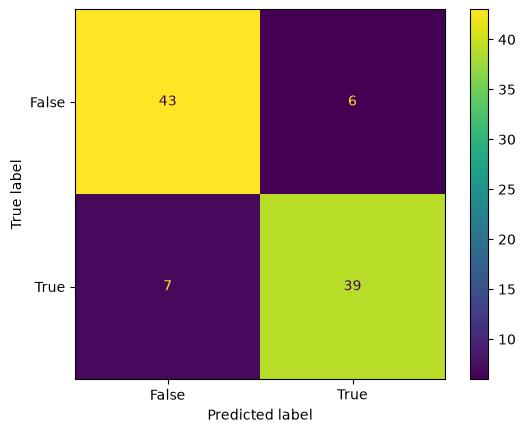

In [36]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [37]:
false_positives = int(((y_pred_series == 1) & (y_test == 0)).sum())
false_negatives = int(((y_pred_series == 0) & (y_test == 1)).sum())

print(f"Falsos positivos (predice enfermo, sano en realidad): {false_positives}")
print(f"Falsos negativos (predice sano, enfermo en realidad): {false_negatives}")

Falsos positivos (predice enfermo, sano en realidad): 6
Falsos negativos (predice sano, enfermo en realidad): 7


### Variables más importantes en los casos mal clasificados

Se mapean las variables transformadas más importantes (según la tabla de Feature Importance MDI) a sus columnas originales en `x_test`, para poder mostrar sus valores en los casos mal clasificados.

In [38]:
cols_numeric = ["age", "chol", "max_hr", "old_peak", "ca"]
cols_categoric = ["sex", "chest_pain", "rest_ecg", "thal"]


def map_to_original_column(feature_name: str) -> str:
    if feature_name.startswith("numeric__"):
        return feature_name.removeprefix("numeric__")
    if feature_name.startswith("boolean__"):
        return feature_name.removeprefix("boolean__")
    if feature_name.startswith("categoric ordinales__"):
        return feature_name.removeprefix("categoric ordinales__")
    if feature_name.startswith("categoric__"):
        remainder = feature_name.removeprefix("categoric__")
        return next(col for col in cols_categoric if remainder.startswith(col))
    raise ValueError(f"Prefijo desconocido: {feature_name}")


top_n = 5
top_original_cols = []
for feature in mdi_importances["feature"].head(top_n):
    original_col = map_to_original_column(feature)
    if original_col not in top_original_cols:
        top_original_cols.append(original_col)

top_original_cols

['ca', 'old_peak', 'age', 'max_hr', 'chol']

In [39]:
x_test.loc[misclassified, top_original_cols].assign(
    y_true=y_test[misclassified], y_pred=y_pred_series[misclassified]
)

,ca,old_peak,age,max_hr,chol,y_true,y_pred
1421,0,1.4,62.0,<NA>,NaN,True,0.0
232,3,0.8,49.0,126,149.0,True,0.0
16,0,1.0,48.0,168,229.0,True,0.0
268,0,0.0,40.0,181,223.0,True,0.0
33,0,0.5,59.0,161,234.0,False,1.0
1484,<NA>,NaN,46.0,<NA>,311.0,True,0.0
1479,<NA>,NaN,59.0,<NA>,218.0,True,0.0
1476,<NA>,NaN,61.0,<NA>,166.0,True,0.0
92,3,1.8,62.0,146,231.0,False,1.0
1279,0,1.6,54.0,165,NaN,False,1.0


### Estadísticas descriptivas: bien clasificados vs. mal clasificados

Se comparan la media, el mínimo y el máximo de las variables numéricas más importantes entre los casos bien clasificados y los mal clasificados, para buscar patrones (valores atípicos, cercanía a los límites de decisión, etc.).

In [40]:
numeric_top_cols = [col for col in top_original_cols if col in cols_numeric]

stats_comparison = pd.concat(
    {
        "bien_clasificados": x_test.loc[~misclassified, numeric_top_cols].agg(
            ["mean", "min", "max"]
        ),
        "mal_clasificados": x_test.loc[misclassified, numeric_top_cols].agg(
            ["mean", "min", "max"]
        ),
    },
    axis=1,
)
stats_comparison

bien_clasificados                                           \
                    ca  old_peak     age      max_hr       chol   
mean          0.657143  1.198507  54.025  151.476923  240.15942   
min           0.000000  0.000000  34.000   95.000000  149.00000   
max           3.000000  6.200000  74.000  194.000000  409.00000   

     mal_clasificados                                 
                   ca old_peak   age   max_hr   chol  
mean              0.7     1.26  54.0  158.125  224.5  
min               0.0     0.00  37.0  126.000  149.0  
max               3.0     3.50  69.0  187.000  311.0

In [41]:
categoric_top_cols = [col for col in top_original_cols if col not in cols_numeric]

for col in categoric_top_cols:
    print(f"--- {col} ---")
    print("Bien clasificados:")
    print(x_test.loc[~misclassified, col].value_counts(normalize=True))
    print("\nMal clasificados:")
    print(x_test.loc[misclassified, col].value_counts(normalize=True))
    print()

## Consecuencias de las malas predicciones

En un modelo de diagnóstico clínico, los dos tipos de error tienen consecuencias distintas. Un **falso negativo** (el modelo predice "sano" cuando el paciente sí tiene la enfermedad) es el error más grave: el paciente no recibiría el seguimiento médico necesario, retrasando un diagnóstico y tratamiento oportuno. Un **falso positivo** (el modelo predice "enfermo" cuando el paciente está sano) tiene consecuencias menos graves pero no despreciables: exámenes adicionales innecesarios, ansiedad del paciente y costos extra para el sistema de salud. Por esta asimetría en la gravedad de las consecuencias, el proyecto prioriza recall (minimizar falsos negativos) como métrica principal, tal como se definió en la Actividad 6.

## Tipo de errores del modelo

Sobre el conjunto de prueba (95 pacientes), el modelo clasifica incorrectamente 13 casos (13.7%): 6 falsos positivos y 7 falsos negativos. Los errores están relativamente balanceados entre ambos tipos, con una ligera inclinación hacia los falsos negativos (7 vs 6), que son los de mayor consecuencia clínica. Esto es consistente con el recall obtenido en la Actividad 6 (0.848 en test): de los pacientes enfermos, la gran mayoría es detectada correctamente, pero persiste un margen de error que no debe ignorarse en un contexto clínico real.

## A qué se deben los errores

Al comparar estadísticas descriptivas de las variables numéricas más importantes (ca, old_peak, age, max_hr, chol) entre casos bien y mal clasificados, no se observan diferencias grandes en las medias (por ejemplo, edad promedio: 54.0 años en ambos grupos), lo que sugiere que los errores no se concentran en un rango etario ni en valores atípicos extremos de estas variables — los rangos min/max de los mal clasificados están dentro del rango de los bien clasificados.

Un patrón que sí se observa: 3 de los 13 casos mal clasificados (índices 1484, 1479, 1476) tienen valores faltantes (NaN) en `ca`, `old_peak` y `max_hr` simultáneamente, y otros 2 casos tienen al menos una de estas variables faltante. Dado que estas son precisamente las variables más importantes según MDI, es razonable pensar que la imputación de valores faltantes (mediana, según el pipeline de la Actividad 4) reduce la información disponible para el modelo en estos casos específicos, aumentando la probabilidad de error. No se observan indicios de errores de ingreso de datos (valores fuera de rango biológicamente plausible) ni de codificación (encoders) incorrecta.

La discrepancia entre MDI y Permutation Importance (esta última señala a `thal`, `chest_pain` y `slope` como más influyentes en el desempeño real) sugiere que el modelo podría estar apoyándose en relaciones entre variables categóricas para los casos límite, un aspecto que no se exploró en profundidad en este análisis y queda como línea de trabajo futuro.

## 📊 Analysis of Results

El modelo Random Forest seleccionado en la Actividad 6 (recall = 0.848, accuracy = 0.863 sobre el test set) fue interpretado usando dos métodos de importancia de variables. Según MDI (Mean Decrease in Impurity), las variables numéricas `ca`, `old_peak`, `age`, `max_hr` y `chol` son las más importantes, con importancias entre 0.098 y 0.130. Sin embargo, la Permutation Importance sobre el test set (usando recall) muestra un panorama distinto: las variables categóricas `thal`, `chest_pain` y `slope` tienen mayor impacto real sobre el desempeño del modelo que la mayoría de las variables numéricas. Esta discrepancia es esperable — MDI tiende a sobrevalorar variables numéricas continuas — y es un hallazgo relevante: no basta con mirar un solo método de importancia para entender qué variables sostienen las predicciones del modelo.

El análisis de errores muestra 13 casos mal clasificados de 95 (13.7%): 6 falsos positivos y 7 falsos negativos, relativamente balanceados. Al revisar los casos mal clasificados, no se encontraron outliers evidentes en las variables numéricas más importantes (las medias y rangos son similares entre bien y mal clasificados), pero sí se identificó que 5 de los 13 casos mal clasificados (38%) tienen valores faltantes en `ca`, `old_peak` o `max_hr` — variables que están entre las más importantes según MDI. Esto sugiere que la imputación de datos faltantes en estas variables clave podría estar contribuyendo a parte de los errores del modelo.

La Learning Curve confirma lo observado en la Actividad 6: persiste una brecha entre el recall de entrenamiento (0.985) y el de validación cruzada (0.825) con el tamaño de muestra actual, pero la tendencia ascendente sin estabilizarse sugiere que más datos seguirían mejorando el desempeño. La escalabilidad del modelo es adecuada: el tiempo de entrenamiento crece de forma moderada (0.080s a 0.099s) al aumentar el tamaño de la muestra de entrenamiento.

## 💡 Recomendaciones

Investigar el origen de los valores faltantes en `ca`, `old_peak` y `max_hr`: dado que están asociados a un porcentaje relevante de los errores del modelo (38% de los casos mal clasificados), valdría la pena entender si el faltante es aleatorio o sistemático (por ejemplo, si ciertos exámenes no se realizan a determinados pacientes), y evaluar estrategias de imputación más sofisticadas que la mediana simple.

Complementar el análisis de importancia de variables: dado que MDI y Permutation Importance no coinciden completamente, en la siguiente iteración conviene priorizar Permutation Importance (por medir el impacto real en el desempeño) al decidir qué variables explorar o recolectar con mayor calidad — en este caso, `thal`, `chest_pain` y `slope`.

Recolectar más datos: como se documentó en la Actividad 6, la Learning Curve no muestra señales de estabilización, por lo que ampliar el tamaño de muestra sigue siendo la mejora con mayor potencial de impacto.

Explorar el uso de SHAP values como complemento a MDI y Permutation Importance, para obtener explicaciones a nivel de predicción individual (por ejemplo, para los 13 casos mal clasificados), lo cual podría dar más claridad sobre por qué el modelo se equivoca en casos específicos.

Estas conclusiones constituyen el listado de pruebas y experimentos a considerar en la siguiente iteración del proyecto, tal como lo solicita el requerimiento de esta actividad.

## 📖 Referencias

- [7. Interpretación del modelo - Curso Ciencia de Datos en Producción](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/)
- [06. Selección del mejor modelo](../5-models/06.ModelSelection-kgnl-20260825.ipynb)
- [Curso de Machine Learning](https://joserzapata.github.io/courses/python-ciencia-datos/ml/)
- [Curso de Clasificación](https://joserzapata.github.io/courses/python-ciencia-datos/clasificacion/)
- [Checklist de un proyecto de Machine Learning](https://joserzapata.github.io/post/lista-proyecto-machine-learning/)